In [1]:
!pip install numpy seaborn matplotlib pandas


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# LAB 2: DATA VISUALIZATION IN PYTHON
**Course:** Data Visualisation  
**Instructor:** Vo Nhat Tan  

### Team Members:
1. [Name 1] - [Student ID 1]
2. [Name 2] - [Student ID 2]
3. [Name 3] - [Student ID 3]
4. [Name 4] - [Student ID 4]

---
### Project Overview
This project utilizes the **World Development Indicators (WDI)** dataset from the World Bank. The objective is to preprocess the data, perform basic statistical analysis, and create visualizations to uncover macroeconomic trends, environmental impacts, and relationships between development indicators.

## 1. Basic Data Analysis

### 1.1. Dataset Introduction
The selected panel dataset has the following structure:
* **Timeframe:** 15 annual observations (**2008-2022**).
* **Geography:** 16 countries, primarily in Asia-Pacific and ASEAN (e.g., Viet Nam, Japan, Australia, China, Singapore).
* **Indicators:** 13 socio-economic and environmental indicators, grouped into 5 dimensions:
  - **Macroeconomy:** GDP growth, inflation, unemployment.
  - **Energy transition:** fossil electricity share, renewable electricity share.
  - **Environment:** CO2 emissions, CH4 emissions.
  - **Human development & infrastructure:** life expectancy, tertiary enrollment, education spending, water access, rural electricity.
  - **Demographic scale:** population.

From structural inspection:
* Raw `data.csv` has **213 rows x 19 columns**.
* The final 5 rows are non-data footer entries from World Bank export metadata.

First, we load the raw dataset to inspect its dimensions, data types, and identify any structural anomalies.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data & Overview
df = pd.read_csv('WDI/data.csv')
print("Size:", df.shape)

df.info()

display(df.head())
display(df.tail())

Size: (213, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   210 non-null    object
 1   Country Code   208 non-null    object
 2   Series Name    208 non-null    object
 3   Series Code    208 non-null    object
 4   2008 [YR2008]  208 non-null    object
 5   2009 [YR2009]  208 non-null    object
 6   2010 [YR2010]  208 non-null    object
 7   2011 [YR2011]  208 non-null    object
 8   2012 [YR2012]  208 non-null    object
 9   2013 [YR2013]  208 non-null    object
 10  2014 [YR2014]  208 non-null    object
 11  2015 [YR2015]  208 non-null    object
 12  2016 [YR2016]  208 non-null    object
 13  2017 [YR2017]  208 non-null    object
 14  2018 [YR2018]  208 non-null    object
 15  2019 [YR2019]  208 non-null    object
 16  2020 [YR2020]  208 non-null    object
 17  2021 [YR2021]  208 non-null    object
 18  2022 [YR2022] 

,Country Name,Country Code,Series Name,Series Code,2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,Brunei Darussalam,BRN,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,..,..,1.84384000301361,3.32213997840881,2.88964009284973,..,3.35321998596191,..,4.42539978027344,..,..,..,..,..,..
1,Brunei Darussalam,BRN,"School enrollment, tertiary (% gross)",SE.TER.ENRR,15.7385101318359,16.5658493041992,15.3331563578444,17.4270912772504,22.0733483384086,23.4649239797279,30.0799102783203,28.6641292572021,28.6644096374512,31.2433910195239,27.9285989469629,27.7715019255456,29.1961193084717,27.4258937503291,31.1925368707703
2,Brunei Darussalam,BRN,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,..,..,..,..,..,..,6.862,..,..,9.316,8.7,6.6,7.409,4.905,5.191
3,Brunei Darussalam,BRN,"Electricity production from oil, gas and coal ...",EG.ELC.FOSL.ZS,100,100,100,99.9463087248322,99.9491094147583,99.9545661063153,99.9556147359077,99.9523809523809,99.9765807962529,99.951888381044,99.9534125320289,99.9594484995945,99.947689625109,99.9122653097035,99.875044626919
4,Brunei Darussalam,BRN,"Electricity production from renewable sources,...",EG.ELC.RNWX.ZS,0,0,0.0213607594936709,0.043489932885906,0.0424936386768448,0.038391640163562,0.0359520639147803,0.0311904761904762,0.0255269320843091,0.0377676208804426,0.037037037037037,0.0218978102189781,0.0193548387096774,0.0196525706264257,..


,Country Name,Country Code,Series Name,Series Code,2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
212,Last Updated: 02/24/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We identify the following structural characteristics and data quality issues:
* **Dataset Scale:** The raw table contains **213 records** and **19 columns** (country keys, indicator keys, and 15 annual columns from 2008 to 2022).
* **Structural Noise (Footer Rows):** The last 5 rows are export metadata (not observations), which appears as missing country identifiers.
* **Missing Placeholder Encoding:** The value `..` is used for unavailable data and must be converted to standard `NaN` for numerical analysis.
* **Data Type Mismatch:** Year columns are imported as `object` because of mixed numeric/placeholder content.

**=>** We need to remove footer rows, clean year labels, convert placeholders to `NaN`, cast year columns to numeric, and preserve a tidy long format for visualization.

### 1.2. Data Cleaning and Reshaping
To prepare for visualization, the data is transformed in 3 steps:
1. **Filtering:** Remove the 5 footer rows and drop redundant identifier columns (`Series Code`, `Country Code`) after structural validation.
2. **Standardization:** Convert `2008 [YR2008]` style headers into plain years (`2008`), replace `..` with `NaN`, and cast all year values to numeric type.
3. **Reshaping (Melt):** Convert from wide format (one column per year) into long format with fields: `Country Name`, `Series Name`, `Year`, `Value`. (required for grouped visualizations in Seaborn/Matplotlib)

We will remove footers, handle placeholders, standardise column names, and reshape the dataset for visualization.

In [14]:
# Drop metadata footers
df_clean = df.dropna(subset=['Country Code']).copy()
df_clean = df_clean.drop(['Series Code', 'Country Code'], axis=1)

# Rename year columns ('2008 [YR2008]' -> '2008')
df_clean = df_clean.rename(columns={col: col.split(' ')[0] for col in df_clean.columns if '[YR' in col})

# Handle placeholders and cast to float
year_cols = sorted([col for col in df_clean.columns if col.isdigit()], key=int)
df_clean[year_cols] = df_clean[year_cols].replace('..', np.nan)
df_clean[year_cols] = df_clean[year_cols].astype(float)

# Melt to Long Format for visualization later
id_vars = ['Country Name', 'Series Name']
df_melted = pd.melt(df_clean, id_vars=id_vars, value_vars=year_cols, var_name='Year', value_name='Value')
df_melted['Year'] = df_melted['Year'].astype(int)

print(f"Rows (long format): {df_melted.shape[0]}")
print(f"Countries: {df_melted['Country Name'].nunique()} | Variables: {df_melted['Series Name'].nunique()}")
print(f"Year range: {df_melted['Year'].min()}-{df_melted['Year'].max()} ({len(year_cols)} years)")

Rows (long format): 3120
Countries: 16 | Variables: 13
Year range: 2008-2022 (15 years)


* The dataset is transformed to **3,120 long records** (**16 countries x 13 indicators x 15 years**).
* The structure now contains 4 standardized fields: `Country Name`, `Series Name`, `Year`, and `Value`.

### 1.3. Missing Value Evaluation
Before determining an imputation strategy, we dissect the missing values across three dimensions: Series, Year, and Country.

In [4]:
# Missing Value Evaluation
missing_counts = df_melted[df_melted['Value'].isnull()].groupby('Series Name').size()
total_counts = df_melted.groupby('Series Name').size()

missing_stats = pd.DataFrame({
    'Missing': missing_counts,
    'Expected': total_counts,
    'Missing (%)': (missing_counts / total_counts) * 100
}).fillna(0).sort_values(by='Missing (%)', ascending=False)
display(missing_stats)

print("\n--- MISSING BY YEAR ---")
print(df_melted[df_melted['Value'].isnull()].groupby('Year').size())

print("\n--- MISSING BY COUNTRY  ---")
print(df_melted[df_melted['Value'].isnull()].groupby('Country Name').size().sort_values(ascending=False).head())

,Missing,Expected,Missing (%)
Series Name,,,
"Government expenditure on education, total (% of GDP)",71.0,240,29.583333
"School enrollment, tertiary (% gross)",53.0,240,22.083333
"Unemployment, total (% of total labor force) (national estimate)",44.0,240,18.333333
"Electricity production from renewable sources, excluding hydroelectric (% of total)",16.0,240,6.666667
"Inflation, consumer prices (annual %)",3.0,240,1.250000
"Electricity production from oil, gas and coal sources (% of total)",1.0,240,0.416667
GDP growth (annual %),0.0,240,0.000000
"Access to electricity, rural (% of rural population)",0.0,240,0.000000
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),0.0,240,0.000000



--- MISSING BY YEAR ---
Year
2008    18
2009    16
2010    12
2011    13
2012    15
2013    14
2014    11
2015    10
2016    11
2017     7
2018     9
2019     7
2020     9
2021     8
2022    28
dtype: int64

--- MISSING BY COUNTRY  ---
Country Name
Myanmar              36
Timor-Leste          25
Australia            20
Brunei Darussalam    19
China                19
dtype: int64


* **By Series:** Missingness is highly concentrated in education and labor indicators. The largest gaps are in *Government expenditure on education* (71), *Tertiary enrollment* (53), and *Unemployment* (44), highlighting the difficulty in collecting public spending data across certain nations.
* **By Year:** Missing values are not only a late-period issue. The highest missing year is **2022 (28 records)**, but earlier years also show substantial gaps (e.g., 2008 and 2009), indicating indicator-specific reporting inconsistency across countries.
* **By Country:** **Myanmar (36)** has the highest missing count, followed by **Timor-Leste (25)** and **Australia (20)**, suggesting country-specific data availability constraints, also with the disruption of its national statistical systems due to severe political and social turmoil in recent years.

### 1.4. Missing hadling
**Rationale:** Aggressive imputation methods (like filling with regional Means or Forward-filling) would generate flat, unrealistic trendlines that mislead the audience.

So we will implement **Linear Interpolation**. Specifically, the parameters `limit=4` and `limit_area='inside'` are configured to:
1. Only bridge small, internal gaps (1-4 years) to smooth out the charts.
2. **Strictly avoid** forging data for large endpoint gaps (e.g., missing 2023 data remains `NaN`).

In [5]:
# Sort the melted DataFrame for interpolation
df_melted = df_melted.sort_values(by=['Country Name', 'Series Name', 'Year'])
df_processed = df_melted.reset_index(drop=True).copy()

# Interpolate max 4 consecutive years, inside existing data points (some countries have long time reporting gaps)
df_processed['Value'] = df_processed.groupby(['Country Name', 'Series Name'])['Value'].transform(
    lambda x: x.interpolate(method='linear', limit=4, limit_area='inside')
)

print("Total missing values before interpolation:", df_melted['Value'].isnull().sum())
print("Total missing values after interpolation:", df_processed['Value'].isnull().sum())

Total missing values before interpolation: 188
Total missing values after interpolation: 138


Total missing values were reduced from **188 to 138**. The method filled **50 short internal gaps** while preserving larger endpoint/data-absence gaps as `NaN`, balancing readability with data honesty.

### 1.5. Descriptive Statistics
With the dataset cleaned and interpolated, we pivot to compute descriptive statistics (count, mean, min, max, standard deviation) across all **13 indicators**.

In [6]:
pivot_df = df_processed.pivot_table(index=['Country Name', 'Year'], 
                                    columns='Series Name', values='Value').reset_index()

print("STATISTICS")
display(pivot_df.describe().T[['count', 'mean', 'min', 'max', 'std']])

STATISTICS


,count,mean,min,max,std
Series Name,,,,,
Year,240.0,2.015000e+03,2008.000000,2.022000e+03,4.329523e+00
"Access to electricity, rural (% of rural population)",240.0,8.840792e+01,11.700000,1.000000e+02,2.104462e+01
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),240.0,9.004619e+02,0.310900,1.255186e+04,2.568095e+03
"Electricity production from oil, gas and coal sources (% of total)",239.0,7.058465e+01,0.000000,1.000000e+02,2.644896e+01
"Electricity production from renewable sources, excluding hydroelectric (% of total)",224.0,6.247243e+00,-9.996215,2.711663e+01,7.131819e+00
GDP growth (annual %),240.0,4.084775e+00,-20.522479,3.172574e+01,4.597826e+00
"Government expenditure on education, total (% of GDP)",183.0,3.583144e+00,0.787440,1.290248e+01,1.823713e+00
"Inflation, consumer prices (annual %)",237.0,3.227385e+00,-1.610680,2.679954e+01,3.903966e+00
"Life expectancy at birth, total (years)",240.0,7.450206e+01,56.364000,8.456000e+01,6.552374e+00


1. **Scale Variance:** Metrics differ drastically in scale (e.g., *GDP growth* in small percentages vs. *Population* up to billion). 
   * *=>* Cross-indicator analysis will require normalization, log scaling, faceting, or explicit dual-axis
2. **Macroeconomic Shocks:** Growth and inflation still show large swings linked to global and domestic shocks.
3. **Infrastructure and human-development heterogeneity persists:** Access indicators (electricity/water) are high in some countries but still lag in others.
4. **Population adds structural context:** Large countries can dominate absolute emissions totals; interpretation should distinguish absolute scale from intensity or efficiency.

### Summary
Based on the foundational analysis and preprocessing, the dataset is now ready for advanced visualization:
* **Structural Integrity:** The cleaned long-format panel has **3,120 rows** with 4 core fields (`Country Name`, `Series Name`, `Year`, `Value`) across **16 countries, 13 indicators, 15 years (2008-2022)**.
* **Data Fidelity:** Missing values were reduced from **188 to 138** without imputing endpoint gaps, preserving reporting realism.
* **Visualization Strategy:** Because variable scales differ drastically, upcoming charts should explicitly control scale (normalization/log/facets) to avoid misleading comparisons.

## 2. Objectives and Feature Selection (Task 2)

This section presents 15 analytical objectives across 5 socio-economic themes. For each objective, we define: (1) target metrics, (2) metric meaning, (3) why the selection is appropriate, and (4) why the chart type is suitable for accurate and readable communication.

### Theme 1: Macroeconomic Trends and Volatility

**Objective 1: Track GDP growth over time (2008-2022)**
- Selected metric: GDP growth (annual %)
- Metric meaning: Year-over-year growth rate of the economy.
- Why this metric fits: It directly measures expansion and contraction across shocks.
- Chart choice: Line chart (time-series), suitable for showing trend direction and turning points.

**Objective 2: Examine inflation-unemployment relationship (Phillips Curve perspective)**
- Selected metrics: Inflation (annual %) and Unemployment (% of labor force)
- Metric meaning: Inflation captures price pressure; unemployment captures labor market slack.
- Why these metrics fit: They are core variables for evaluating potential short-run trade-offs.
- Chart choice: Scatter plot with trendline, suitable for assessing association between two numerical variables.

**Objective 3: Compare GDP growth stability across countries**
- Selected metric: GDP growth (annual %)
- Metric meaning: Distribution of yearly growth outcomes by country.
- Why this metric fits: Stability is a distribution question, not only an average question.
- Chart choice: Boxplot, suitable for comparing median, spread, and outliers across categories.

---

### Theme 2: Energy Transition and Environmental Impact

**Objective 4: Assess the shift from fossil to renewable electricity**
- Selected metrics: Electricity from oil/gas/coal (%) and electricity from renewables (%)
- Metric meaning: Shares of electricity generation by source type.
- Why these metrics fit: They represent energy-system composition over time.
- Chart choice: Stacked area chart, suitable for showing changing composition in a time-series context.

**Objective 5: Analyze growth-emissions relationship under population scale**
- Selected metrics: GDP growth (annual %), CO2 emissions (Mt CO2e), Population (total)
- Metric meaning: Population measures total residents. Other metrics capture social welfare outcomes versus environmental costs, providing demographic scale context.
- Why these metrics fit: They help separate growth effects from country-size effects in cross-country comparison.
- Chart choice: Bubble chart, where bubble size represents population scale.

**Objective 6: Track CO2 emissions trend (2008-2022)**
- Selected metric: CO2 emissions (Mt CO2e)
- Metric meaning: Total carbon emissions linked to production and energy use.
- Why this metric fits: It is a direct indicator of environmental burden over time.
- Chart choice: Line chart, suitable for long-run trend and inflection analysis.

---

### Theme 3: Human Capital and Educational Investment

**Objective 7: Evaluate government priority for education**
- Selected metric: Government expenditure on education (% of GDP)
- Metric meaning: Public education spending relative to economic size.
- Why this metric fits: It standardizes policy commitment for cross-country comparison.
- Chart choice: Horizontal bar chart (country average), suitable for ranking and readability.

**Objective 8: Examine education investment and tertiary enrollment**
- Selected metrics: Government education expenditure and tertiary enrollment (% gross)
- Metric meaning: Input (public spending) versus participation outcome (enrollment).
- Why these metrics fit: They represent a plausible policy-to-outcome relationship.
- Chart choice: Scatter plot, suitable for evaluating whether higher investment aligns with higher participation.

**Objective 9: Monitor expansion of tertiary education access**
- Selected metric: Tertiary enrollment (% gross)
- Metric meaning: Enrollment intensity in higher education relative to official age groups.
- Why this metric fits: It captures long-term human capital expansion.
- Chart choice: Line chart, suitable for multi-year progress tracking.

---

### Theme 4: Infrastructure and Public Health

**Objective 10: Measure progress in rural electrification**
- Selected metric: Access to electricity, rural (% of rural population)
- Metric meaning: Share of rural population with electricity access.
- Why this metric fits: It directly reflects infrastructure inclusion.
- Chart choice: Line chart, suitable for observing progress trajectories by country.

**Objective 11: Evaluate water access and life expectancy relationship**
- Selected metrics: Basic drinking water access (%) and life expectancy at birth (years)
- Metric meaning: Public service coverage versus health outcomes.
- Why these metrics fit: They represent a plausible structural linkage in development.
- Chart choice: Scatter plot, suitable for testing whether better service access aligns with longer lifespan.

**Objective 12: Compare life expectancy distribution across countries**
- Selected metric: Life expectancy at birth (years)
- Metric meaning: Expected years of life under current mortality conditions.
- Why this metric fits: It summarizes overall health performance and inequality.
- Chart choice: Boxplot, suitable for comparing central tendency and dispersion across countries.

---

### Theme 5: Multi-Dimensional Synthesis

**Objective 13: Build a cross-indicator correlation overview**
- Selected metrics: All **13** numeric indicators
- Metric meaning: Pairwise linear relationships across economic, social, environmental, and demographic dimensions.
- Why these metrics fit: A system-level scan is needed before deeper modeling.
- Chart choice: Correlation heatmap, suitable for compactly presenting many relationships at once.

**Objective 14: Examine tertiary enrollment and unemployment**
- Selected metrics: Tertiary enrollment (% gross) and unemployment (%)
- Metric meaning: Education participation versus labor market absorption pressure.
- Why these metrics fit: They test whether education expansion is associated with lower unemployment.
- Chart choice: Scatter plot, suitable for identifying relationship pattern and dispersion.

**Objective 15: Explore modernization trade-off (quality of life vs emissions)**
- Selected metrics: Life expectancy at birth (years), CO2 emissions, Population (total)
- Metric meaning: Population measures total residents. Other metrics capture social welfare outcomes versus environmental costs, providing demographic scale context
- Why these metrics fit: They capture a central development trade-off while preventing over-interpretation of absolute emissions alone.
- Chart choice: Bubble chart, where x = life expectancy, y = CO2 emissions, and bubble size = population.

## 3. Visualization and Analysis

### Theme 1: Macroeconomic Trends and Volatility

**Objective 1: Track GDP growth over time (2008-2022)**
*   **Chart Choice:** Line chart. Time-series data is best represented by lines to clearly show trajectories, peaks, and troughs over the years.
*   **Design Choice:** Plotting 16 countries simultaneously can create a confusing "spaghetti plot". We will highlight a few key economies (e.g., Vietnam, China, Australia, Japan) and fade the rest into the background to make the trends readable.

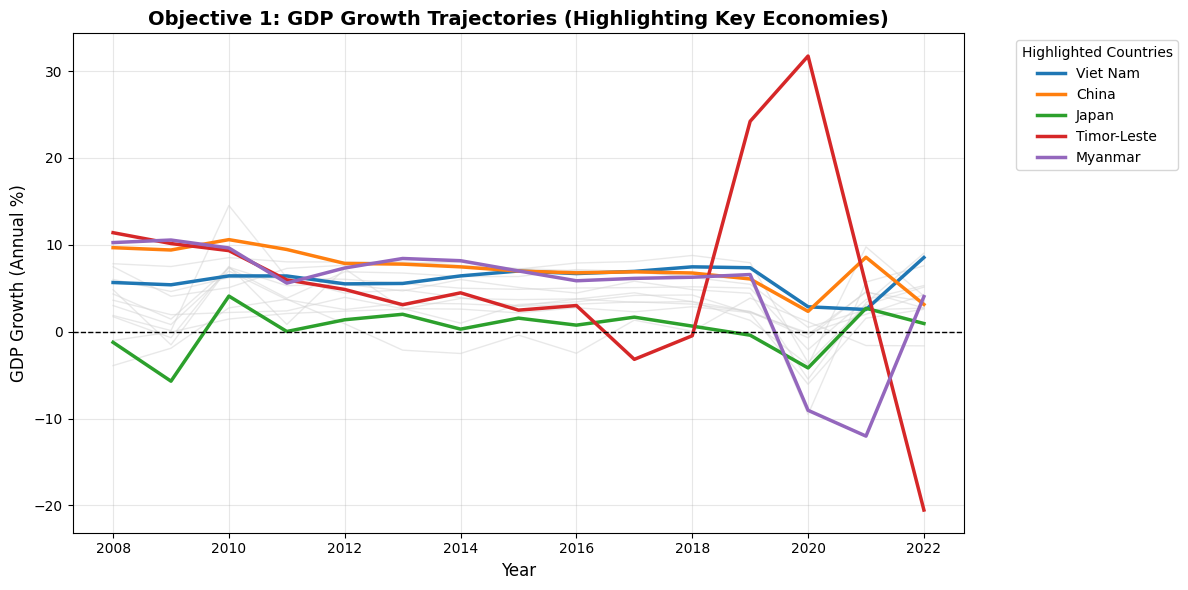

In [7]:
# Objective 1 Code
plt.figure(figsize=(12, 6))

# Define key countries to highlight
# VN, Timor Leste, Myanma, China, Japan
# highlight_countries = ['Viet Nam', 'China', 'Australia', 'Japan', 'Korea', 'New Zealand', 'Timor-Leste', 'Thailand', 'Singapore', 'Philippines', 'Myanmar', 'Malaysia', 'Lao PDR', 'Indonesia', 'Cambodia', 'Brunei Darussalam']
highlight_countries = ['Viet Nam', 'China', 'Japan', 'Timor-Leste', 'Myanmar']
palette = sns.color_palette("tab10", len(highlight_countries))

# Plot background countries (light gray)
for country in pivot_df['Country Name'].unique():
    if country not in highlight_countries:
        country_data = pivot_df[pivot_df['Country Name'] == country]
        sns.lineplot(data=country_data, x='Year', y='GDP growth (annual %)', color='lightgray', alpha=0.5, linewidth=1)

# Plot highlighted countries (colored and bold)
for idx, country in enumerate(highlight_countries):
    country_data = pivot_df[pivot_df['Country Name'] == country]
    sns.lineplot(data=country_data, x='Year', y='GDP growth (annual %)', color=palette[idx], label=country, linewidth=2.5)

# Add horizontal line at 0% for baseline reference
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Objective 1: GDP Growth Trajectories (Highlighting Key Economies)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP Growth (Annual %)', fontsize=12)
plt.legend(title='Highlighted Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 1):**
* **General Trend:** Most economies grow at 10% or less per year, though some experience negative growth in certain years. 
* **High Instability (Timor-Leste):** Timor-Leste is the most unstable country on the chart. Its growth dropped from 11% in 2008 to 0% in 2018, after that it to 30% in 2020, and then dropped massively to -20% in 2022.
* **Stable Growth (Viet Nam):** Viet Nam shows very stable economic performance, keeping a consistent growth rate of around 5% per year.
* **Stagnation (Japan):** Japan's economy is stagnating. Its annual growth rate is very small and drops into negative numbers in multiple years.
* **Slowing Growth (China):** China's growth rate is relatively stable but shows a clear, gradual slowdown over time, dropping from about 10% in 2008 to around 5% in 2022.
* **Sudden Decline (Myanmar):** Myanmar maintained stable growth until around 2019. The economy then shrank significantly over the next two years before finally growing again in 2022.
---

**Objective 2: Examine inflation-unemployment relationship (Phillips Curve perspective)**
*   **Chart Choice:** Scatter plot with a regression line. This is the optimal chart for determining the correlation between two numerical variables.

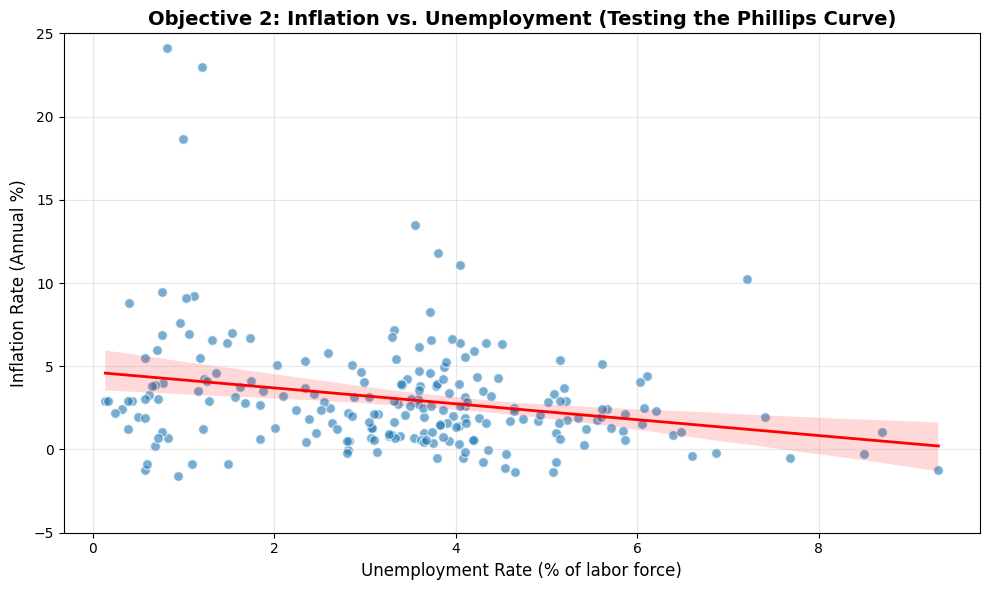

In [8]:
# Objective 2 Code
plt.figure(figsize=(10, 6))

# Scatter plot with regression line to show overall trend
sns.regplot(data=pivot_df, 
            x='Unemployment, total (% of total labor force) (national estimate)', 
            y='Inflation, consumer prices (annual %)', 
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 50},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Objective 2: Inflation vs. Unemployment (Testing the Phillips Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (% of labor force)', fontsize=12)
plt.ylabel('Inflation Rate (Annual %)', fontsize=12)

# Restrict axes slightly to avoid extreme outliers squishing the chart
plt.ylim(-5, 25) 
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 2):**
* **Inverse Relationship:** The graph shows a general inverse relationship, higher inflation correlates with lower unemployment. When unemployment is very low (around 1%), inflation averages near 5%. When unemployment is high (around 8%), inflation drops close to 0%. 
* **Weak Correlation:** This relationship is very weak. The data points are scattered far away from the trendline. For example, at a 4% unemployment rate, actual inflation varies drastically across different countries and years, ranging anywhere from -2% to about 14%.
---

**Objective 3: Compare GDP growth stability across countries**
*   **Chart Choice:** Boxplot. A boxplot excellently summarizes the distribution, central tendency (median), and volatility (IQR and outliers) of GDP growth for each country over the 15-year period.

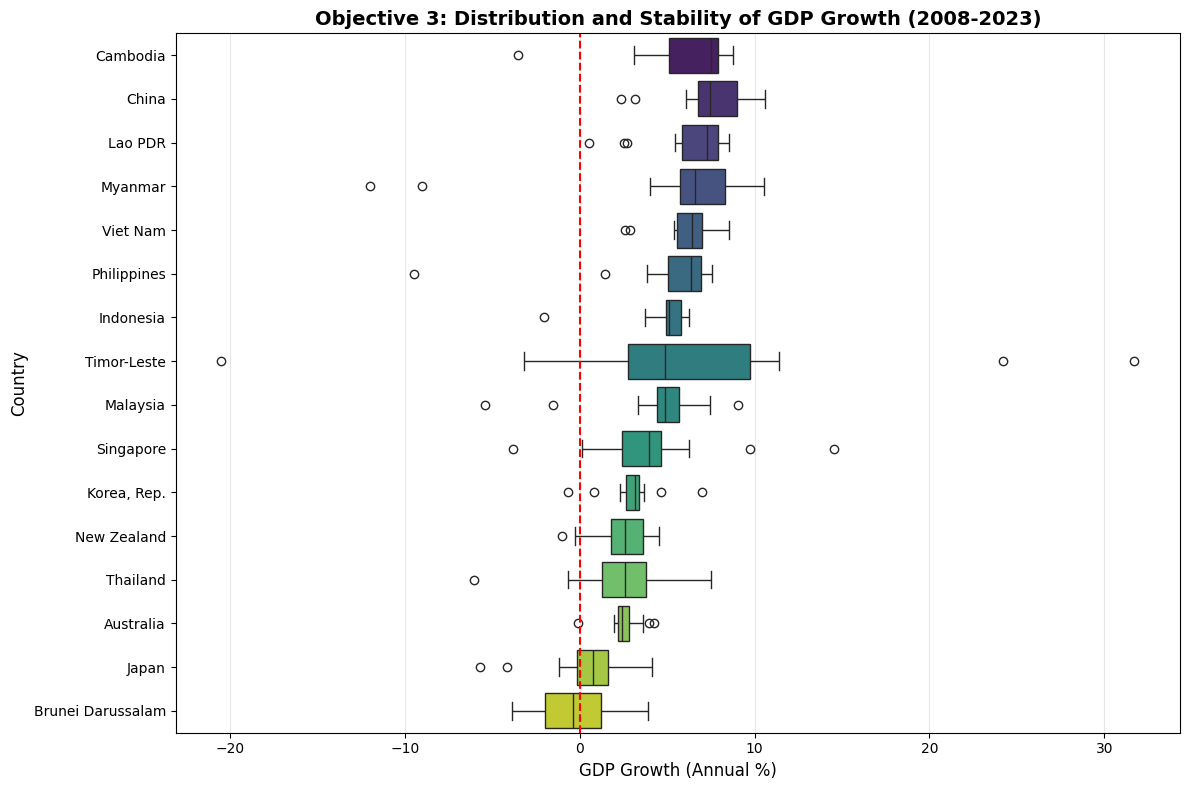

In [ ]:
# Objective 3 Code
plt.figure(figsize=(12, 8))

# Calculate median GDP growth per country for sorting
median_gdp = pivot_df.groupby('Country Name')['GDP growth (annual %)'].median().sort_values(ascending=False)

# Boxplot sorted by median
sns.boxplot(data=pivot_df, 
            x='GDP growth (annual %)', 
            y='Country Name', 
            order=median_gdp.index,
            palette='viridis')

plt.axvline(0, color='red', linestyle='--', linewidth=1.5) # 0% growth reference line

plt.title('Objective 3: Distribution and Stability of GDP Growth (2008-2022)', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth (Annual %)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

reiterate what was said in objective 1

important to note the difference between objective 1 and 3. 1 is to tell the state of the economy in a specific year or from year to year, 3 is to tell the state of the economy in the entire period (grow or stagnate or decline)

**Analysis & Conclusion (Objective 3):**
* **Overall Growth vs. Stagnation:** Most countries have a positive median growth rate, meaning their economies generally grew over the period. Only Japan shows a median close to 0%, confirming its long-term economic stagnation.
* **Stable Performers (Viet Nam & China):** Viet Nam and China rank highly for median growth (around 5-7%) and have very narrow boxes. This confirms they had consistent, rapid economic expansion with minimal fluctuation over the entire period.
* **High Instability (Timor-Leste):** Timor-Leste's box and whiskers are extremely wide, and it has outliers reaching above 30% and below -20%, confirming it was the most unstable economy over the 15 years.
* **Short-term Decline (Myanmar):** Myanmar has a narrow box, indicating its economy was mostly stable. However, it has severe outlier points around -10% and -12%, confirming a significant economic decline for a short time.

### Theme 2: Energy Transition and Environmental Impact

**Objective 4: Assess the shift from fossil to renewable electricity**
*   **Chart Choice:** Stacked Area Chart (Regional Average). This chart type perfectly illustrates the composition of a whole (total electricity generation types) and how those proportions evolve over time.

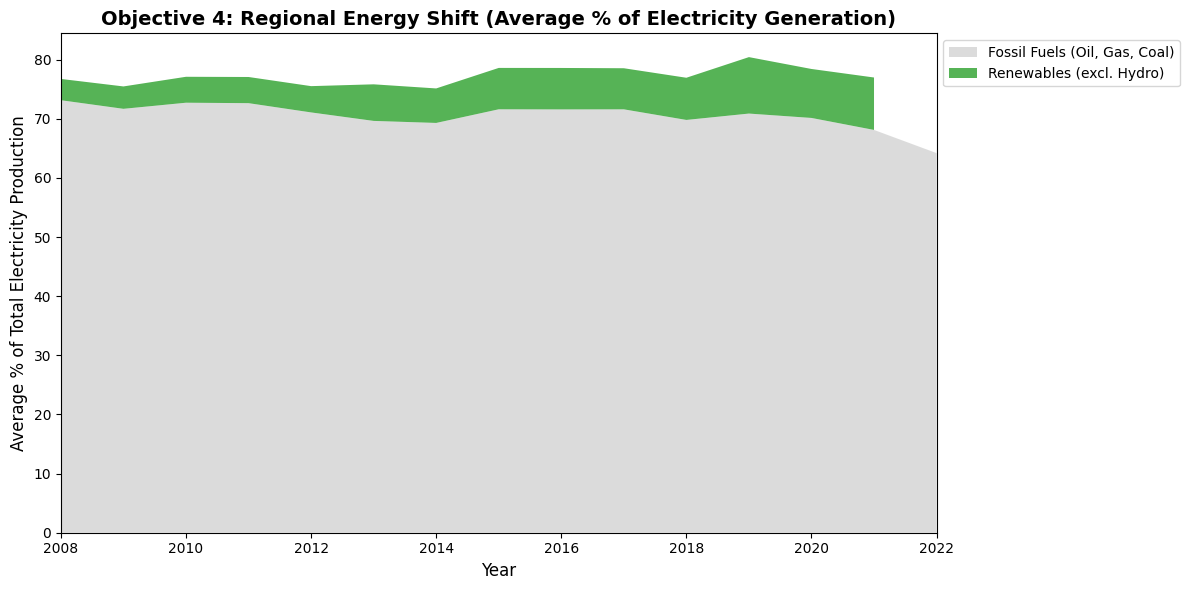

In [10]:
# Objective 4 Code
plt.figure(figsize=(12, 6))

# Calculate regional average per year
energy_trends = pivot_df.groupby('Year')[['Electricity production from oil, gas and coal sources (% of total)', 
                                          'Electricity production from renewable sources, excluding hydroelectric (% of total)']].mean()

plt.stackplot(energy_trends.index, 
              energy_trends['Electricity production from oil, gas and coal sources (% of total)'], 
              energy_trends['Electricity production from renewable sources, excluding hydroelectric (% of total)'],
              labels=['Fossil Fuels (Oil, Gas, Coal)', 'Renewables (excl. Hydro)'],
              colors=['#d3d3d3', '#2ca02c'], alpha=0.8)

plt.title('Objective 4: Regional Energy Shift (Average % of Electricity Generation)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average % of Total Electricity Production', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.margins(x=0)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 4):**
* **Fossil Fuel Dominance:** Energy from fossil fuels is still dominant in the region. It accounted for roughly 73% of total electricity production in 2008 and remained high at approximately 64% by 2022.
* **Renewable Energy Growth:** There is a clear trend of using more renewable energy over the 15-year period. The share of renewable energy grew steadily from only about 3% in 2008 to over 5% by 2021.

---



**Objective 5: Analyze growth-emissions relationship under population scale**
* **Chart Choice:** Bubble Chart (Scatter plot with Logarithmic Y-axis and Size mapping). Carbon emissions vary drastically (ten-thousands (China) vs single (Timor-Leste)), a log scale on the Y-axis is necessary to prevent data overlap at the bottom. Furthermore, by mapping **Population** to the bubble size,we can observe whether emissions are driven by economic growth speed or sheer demographic scale.

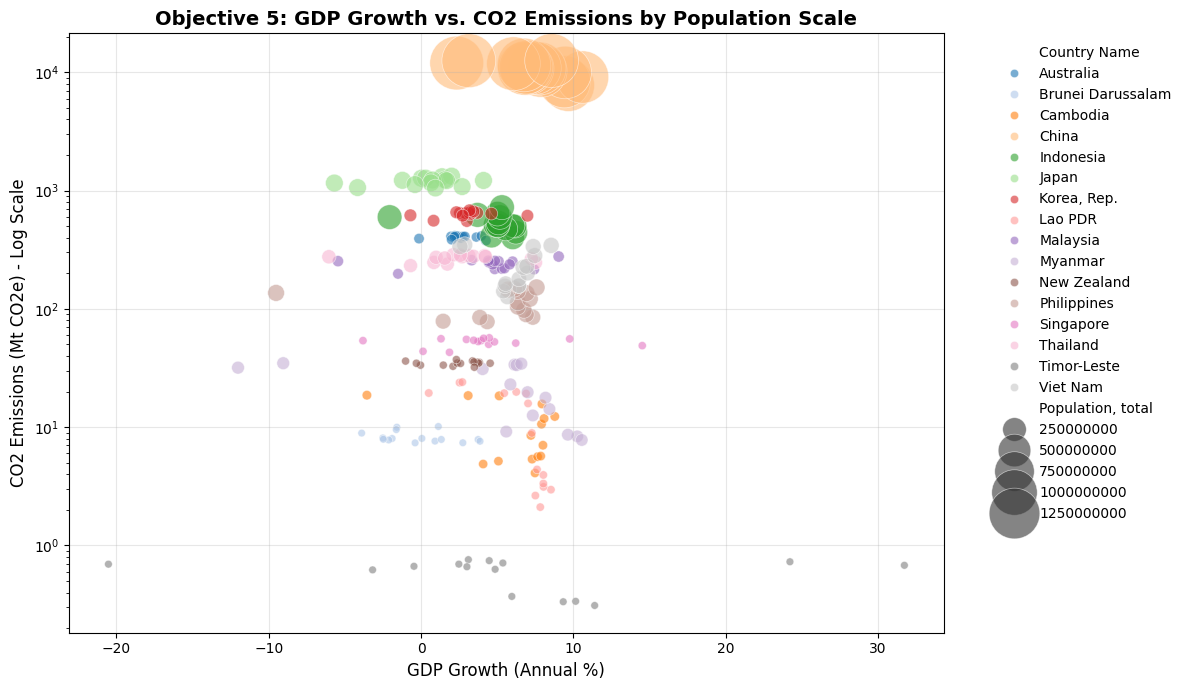

In [15]:
# Objective 5 Code
plt.figure(figsize=(12, 7))

# Create the Bubble Chart by adding the 'size' and 'sizes' parameters
sns.scatterplot(
    data=pivot_df, 
    x='GDP growth (annual %)', 
    y='Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)', 
    size='Population, total',          
    sizes=(30, 1500),                 
    hue='Country Name', 
    palette='tab20', 
    alpha=0.6,                         
    edgecolor='white',              
    linewidth=0.5
)

# Logarithmic scale for CO2 emissions to handle extreme scale variance
plt.yscale('log')

plt.title('Objective 5: GDP Growth vs. CO2 Emissions by Population Scale', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth (Annual %)', fontsize=12)
plt.ylabel('CO2 Emissions (Mt CO2e) - Log Scale', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

China is the biggest emitter (highest on the Y-axis with the largest bubble size), while Timor-Leste is the smallest.

Growth rate tends to hover between 0-10%. There's no clear relation between GDP growth and CO2 emissions (at identical GDP growth rates like 0%, 2%, 4%, and 8%, we still see emissions ranging drastically from $10^0$ to over $10^4$).

Population (represented by the bubble size) clearly acts as the dominant factor dictating the total emission volume. The larger the population, the higher the absolute CO2 emissions, completely independent of how fast the economy is growing.

**Analysis & Conclusion (Objective 5):**
* **Scale of Emissions:** The log scale and bubble sizes reveal distinct tiers of emitters. Massive populations like China and Japan occupy the highest emission tier, entirely regardless of their annual GDP growth rate. 
* **Decoupling & Demographics:** Developed nations (e.g., Japan, Australia) hover around low GDP growth but maintain high absolute emissions. Emerging nations show high growth but significantly lower absolute emissions. There is no strict linear rule that higher annual growth immediately guarantees higher total emissions; demographic and industrial scale (population size) matter far more.

---

**Objective 6: Track CO2 emissions trend (2008-2022)**
*   **Chart Choice:** Line chart with Log Scale. Similar to Objective 5, the immense gap between China and smaller ASEAN nations requires a log-scaled Y-axis to observe individual country trends over time.

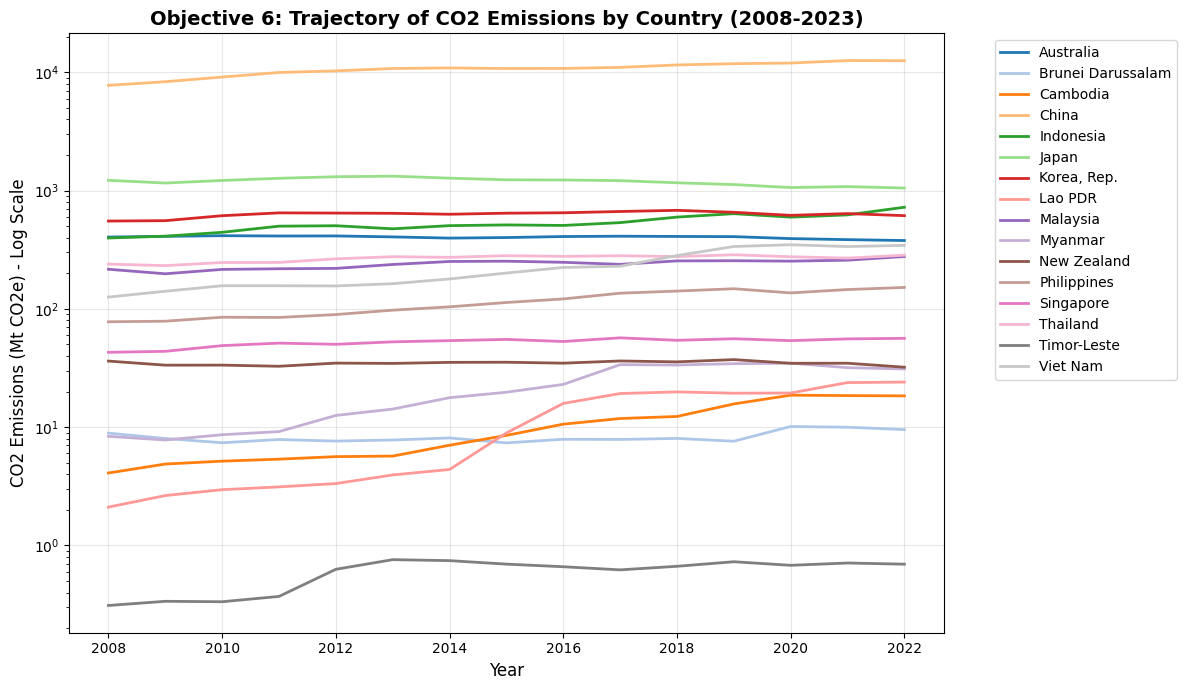

In [ ]:
# Objective 6 Code
plt.figure(figsize=(12, 7))

sns.lineplot(data=pivot_df, 
             x='Year', 
             y='Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)', 
             hue='Country Name', 
             palette='tab20', linewidth=2)

# Logarithmic scale
plt.yscale('log')

plt.title('Objective 6: Trajectory of CO2 Emissions by Country (2008-2022)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Emissions (Mt CO2e) - Log Scale', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 6):**
*   **Emission Trajectories:** Most developed nations (Australia, Japan, New Zealand) show a slow but steady decline in emissions over the 15-year period.
*   **Developing Growth:** Conversely, rapidly industrializing nations (Vietnam, Indonesia, China) show steady upward slopes. This visualizes the core global climate dilemma: developing nations are increasing emissions to fuel economic catch-up, while developed nations are slowly decarbonizing.

### Theme 3: Human Capital and Educational Investment

**Objective 7: Evaluate government priority for education**
*   **Chart Choice:** Horizontal Bar Chart. A bar chart is the most effective way to rank categorical data (countries) based on a numeric value (average expenditure). Sorting the bars makes the comparison instantly readable.

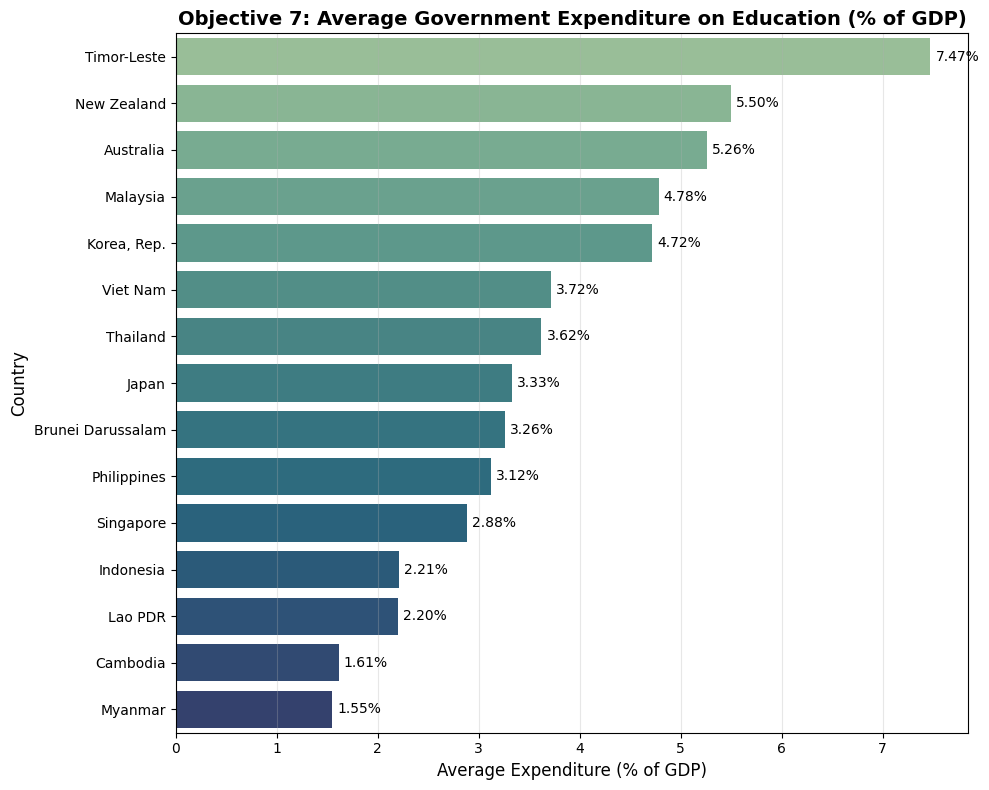

In [13]:
# Objective 7 Code
plt.figure(figsize=(10, 8))

# Calculate average education expenditure per country over the available years
edu_expenditure = pivot_df.groupby('Country Name')['Government expenditure on education, total (% of GDP)'].mean().sort_values(ascending=False)

# Drop countries with entirely NaN values for this metric to clean up the chart
edu_expenditure = edu_expenditure.dropna()

sns.barplot(x=edu_expenditure.values, y=edu_expenditure.index, palette='crest')

plt.title('Objective 7: Average Government Expenditure on Education (% of GDP)', fontsize=14, fontweight='bold')
plt.xlabel('Average Expenditure (% of GDP)', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Add value labels to the end of the bars
for index, value in enumerate(edu_expenditure.values):
    plt.text(value + 0.05, index, f'{value:.2f}%', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 7):**
* **Top Spender (Timor-Leste):** Timor-Leste spends the most on education, averaging 7.47% of its GDP over the period.
* **High Spenders (New Zealand & Australia):** New Zealand and Australia follow, both spending over 5% of their GDP on education (5.50% and 5.26%).
* **Middle Group:** The majority of the countries, including Viet Nam, Thailand, and Japan, spend between 3% and 4.7% of their GDP on education.
* **Lowest Spenders (Myanmar & Cambodia):** Myanmar (1.55%) and Cambodia (1.61%) spend the least on education. The gap between the highest and lowest spending countries is very wide (nearly 6%).